# 04 — Análisis Regional

La tuberculosis activa afecta preferentemente los lóbulos superiores del pulmón.
Este notebook investiga si esa diferencia es visible y cuantificable dividiendo
cada imagen en 6 regiones anatómicas.

**Objetivo:** justificar por qué en el notebook `05_Extraccion_Caracteristicas.ipynb`
se calculan features por región además de features globales.

```
┌─────────────┬─────────────┐
│  SI         │  SD         │  ← zona superior
├─────────────┼─────────────┤
│  MI         │  MD         │  ← zona media
├─────────────┼─────────────┤
│  II         │  ID         │  ← zona inferior
└─────────────┴─────────────┘
     col 0–127    col 128–255     (sobre imagen 256×256)
```

In [1]:
import os
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

In [2]:
DATA_ROOT  = os.path.join(os.path.expanduser('~'), '.cache', 'kagglehub',
                          'datasets', 'usmanshams', 'tbx-11', 'versions', '1', 'TBX11K')
IMG_SIZE   = (256, 256)
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')
PALETTE    = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}

records = []
imgs_dir = Path(DATA_ROOT) / 'imgs'
for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            records.append({'image_path': str(f), 'class_name': class_name, 'label': label})

df_base = pd.DataFrame(records)
print(f'Imágenes cargadas: {len(df_base)}')

def preprocess(path: str) -> np.ndarray | None:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=80, sigmaSpace=80)
    clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8))
    return clahe.apply(img)

REGIONS = {
    'SI': (0,   0,   128, 86),
    'SD': (128, 0,   128, 86),
    'MI': (0,   86,  128, 85),
    'MD': (128, 86,  128, 85),
    'II': (0,   171, 128, 85),
    'ID': (128, 171, 128, 85),
}

Imágenes cargadas: 8400


---
## 1. Visualización de las regiones

Se dibuja la división sobre una imagen preprocesada de cada clase.

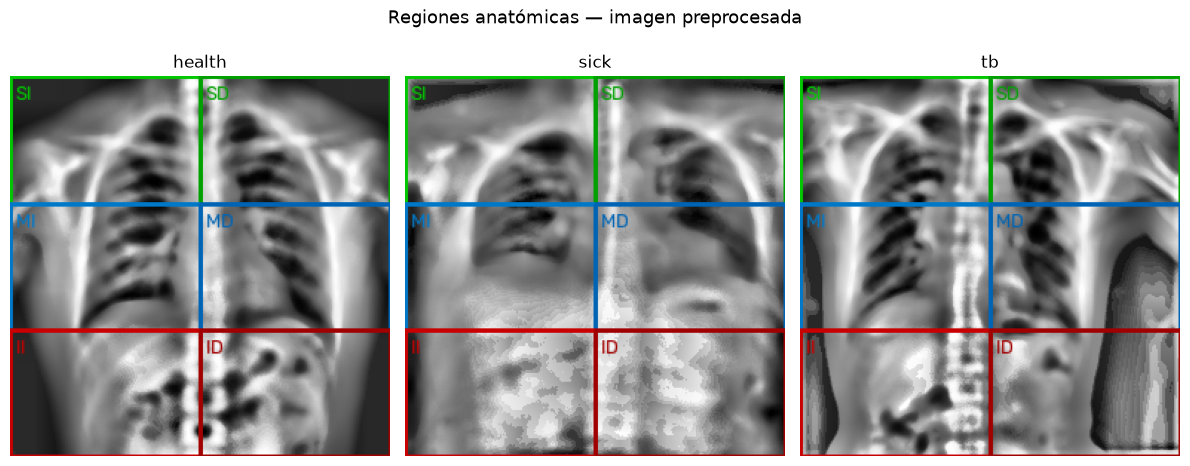

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
colores_region = [
    (0, 200, 0), (0, 160, 0),
    (200, 120, 0), (180, 100, 0),
    (0, 0, 200), (0, 0, 160),
]

for ax, class_name in zip(axes, ['health', 'sick', 'tb']):
    path    = df_base[df_base['class_name'] == class_name].iloc[0]['image_path']
    img_rgb = cv2.cvtColor(preprocess(path), cv2.COLOR_GRAY2BGR)

    for (name, (x, y, w, h)), color in zip(REGIONS.items(), colores_region):
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img_rgb, name, (x+4, y+16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    ax.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
    ax.set_title(class_name, fontsize=12)
    ax.axis('off')

plt.suptitle('Regiones anatómicas — imagen preprocesada', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Intensidad media por región y clase

Si la TB afecta más los lóbulos superiores, `SI` y `SD` deberían tener
intensidades distintas en imágenes `tb` comparado con `health`.
El heatmap hace esa comparación de un vistazo.

In [4]:
N_REG = 60
reg_stats = []

for class_name in ['health', 'sick', 'tb']:
    muestras = df_base[df_base['class_name'] == class_name].sample(N_REG, random_state=42)
    for _, row in muestras.iterrows():
        img = preprocess(row['image_path'])
        if img is None:
            continue
        entry = {'class_name': class_name}
        for name, (x, y, w, h) in REGIONS.items():
            entry[f'{name}_mean'] = float(np.mean(img[y:y+h, x:x+w]))
        reg_stats.append(entry)

reg_df = pd.DataFrame(reg_stats)
region_cols = [f'{r}_mean' for r in REGIONS]

print('Intensidad media por región y clase:')
print(reg_df.groupby('class_name')[region_cols].mean().round(1))

Intensidad media por región y clase:
            SI_mean  SD_mean  MI_mean  MD_mean  II_mean  ID_mean
class_name                                                      
health        120.5    122.2    124.2    126.7    127.3    123.6
sick          126.8    127.6    126.6    130.1    144.6    139.1
tb            125.2    126.8    123.6    127.8    132.6    131.3


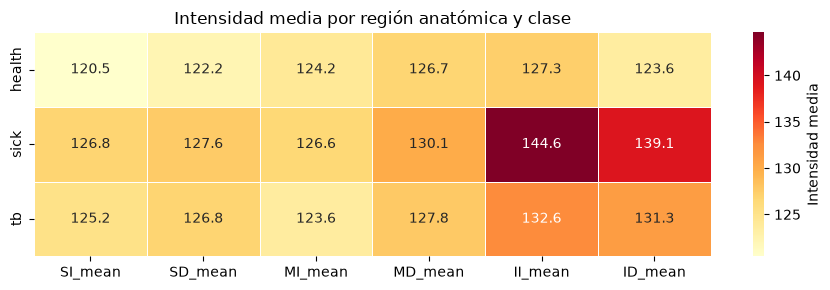

In [5]:
media_regional = reg_df.groupby('class_name')[region_cols].mean()

plt.figure(figsize=(9, 3))
sns.heatmap(
    media_regional, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.5,
    cbar_kws={'label': 'Intensidad media'}
)
plt.title('Intensidad media por región anatómica y clase')
plt.ylabel('')
plt.tight_layout()
plt.show()

---
## 3. Distribución por región

Los violines muestran si las diferencias observadas en el heatmap son consistentes
o si hay mucha variabilidad dentro de cada clase.

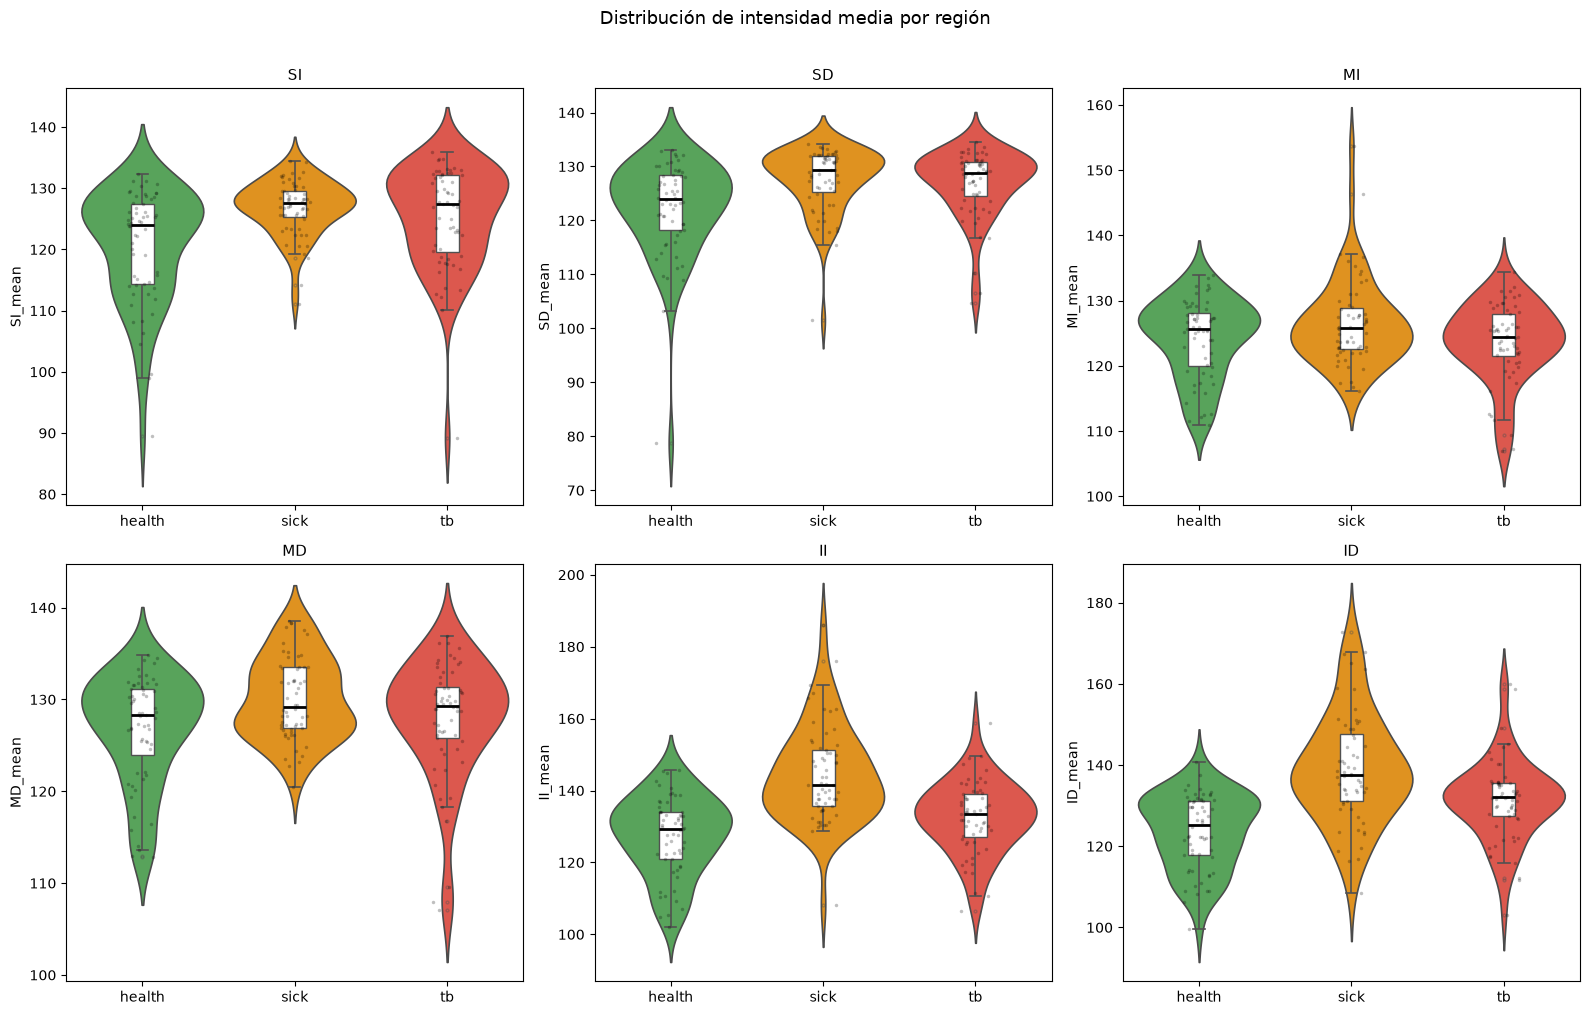

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, region_cols):
    sns.violinplot(
        data=reg_df, x='class_name', y=col,
        order=['health','sick','tb'], palette=PALETTE,
        inner=None, linewidth=1.2, ax=ax
    )
    sns.boxplot(
        data=reg_df, x='class_name', y=col,
        order=['health','sick','tb'], width=0.15,
        boxprops=dict(facecolor='white', zorder=2),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
        ax=ax
    )
    sns.stripplot(
        data=reg_df, x='class_name', y=col,
        order=['health','sick','tb'],
        color='black', alpha=0.25, size=2.5, jitter=True, ax=ax
    )
    ax.set_title(col.replace('_mean', ''), fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Distribución de intensidad media por región', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()